In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("data/patients_cancer_poumon.csv")
df.head()

,patient_id,age,sexe_masculin,presence_nodule,subtilite_nodule,taille_nodule_px,x_nodule_norm,y_nodule_norm,tabagisme_paquets_annee,toux_chronique,dyspnee,douleur_thoracique,perte_poids,spo2,antecedent_familial,risque_malignite,classe_jsrt_source,diagnostic_source,cancer_image,image_path
0,JPCLN001,53,1,1,5,1,0.7979,0.3379,34.9,1,1,1,1,92,0,2,malin,malignant,1,jsrt_subset/malin/JPCLN001.jpg
1,JPCLN002,78,0,1,5,1,0.7881,0.5322,31.4,1,0,0,0,95,0,1,benin,benign,0,jsrt_subset/benin/JPCLN002.jpg
2,JPCLN003,63,0,1,5,1,0.6362,0.2183,34.9,1,1,1,1,92,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN003.jpg
3,JPCLN004,68,0,1,5,1,0.2959,0.4082,28.4,1,0,0,0,95,0,1,benin,benign,0,jsrt_subset/benin/JPCLN004.jpg
4,JPCLN005,73,0,1,5,1,0.7021,0.3379,37.9,1,1,1,1,92,1,2,malin,malignant,1,jsrt_subset/malin/JPCLN005.jpg


In [18]:
features = [
    "age",
    "sexe_masculin",
    "presence_nodule",
    "subtilite_nodule",
    "x_nodule_norm",
    "y_nodule_norm",
    "tabagisme_paquets_annee",
    "toux_chronique",
    "dyspnee",
    "douleur_thoracique",
    "perte_poids",
    "spo2"
]

X_tab_full = df[features].copy()
y_tab_full = df["risque_malignite"].copy()
y_image_full = df["cancer_image"].copy()

In [32]:
indices = np.arange(len(df))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_image_full
)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier()
}


Logistic Regression
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



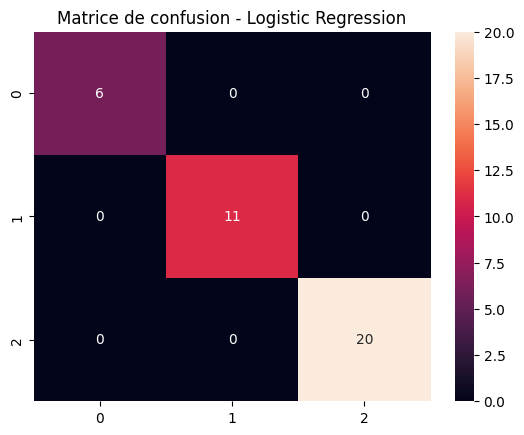


Random Forest
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



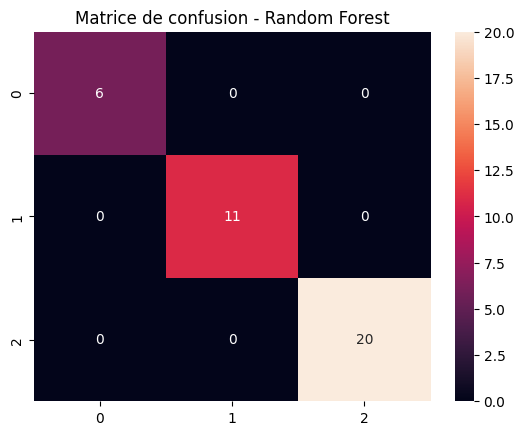


Gradient Boosting
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        20

    accuracy                           1.00        37
   macro avg       1.00      1.00      1.00        37
weighted avg       1.00      1.00      1.00        37



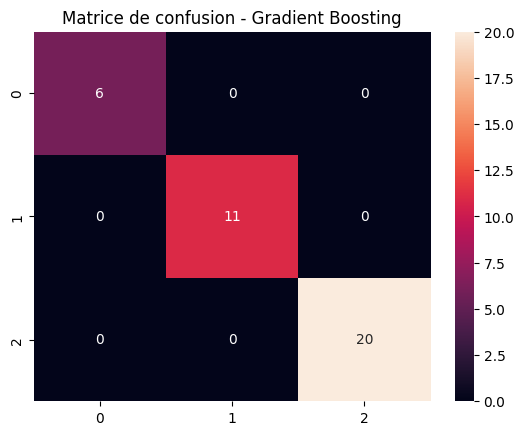

In [23]:
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Matrice de confusion - {name}")
    plt.show()

In [24]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Best model:", best_model_name)

Best model: Logistic Regression


In [25]:
probas = best_model.predict_proba(X_test_scaled)

proba_df = pd.DataFrame(
    probas,
    columns=["faible", "intermediaire", "eleve"]
)

proba_df.head()

,faible,intermediaire,eleve
0,0.000434,0.005651,0.993914
1,0.000244,0.005465,0.994291
2,0.000639,0.003069,0.996292
3,0.004600,0.983906,0.011495
4,0.005055,0.982796,0.012149


In [26]:
import joblib

joblib.dump(best_model, "models/model_tabulaire.pkl")
joblib.dump(scaler, "models/scaler_tab.pkl")

['models/scaler_tab.pkl']

In [27]:
import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.models import Sequential

In [28]:
IMG_SIZE = 128

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    img = np.expand_dims(img, axis=-1)
    return img

X_images = np.array([load_image("data/" + p) for p in df["image_path"]])
y_image = df["cancer_image"]

In [33]:
X_tab_train = X_tab_full.iloc[train_idx]
X_tab_test = X_tab_full.iloc[test_idx]

y_train_tab = y_tab_full.iloc[train_idx]
y_test_tab = y_tab_full.iloc[test_idx]

y_train_img = y_image_full.iloc[train_idx]
y_test_img = y_image_full.iloc[test_idx]

In [34]:
scaler = StandardScaler()

X_tab_train_scaled = scaler.fit_transform(X_tab_train)
X_tab_test_scaled = scaler.transform(X_tab_test)

In [35]:
X_img_train = X_images[train_idx]
X_img_test = X_images[test_idx]

In [37]:
def build_cnn():
    model = Sequential([
        layers.Conv2D(32, (3,3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 1)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [38]:
cnn_model = build_cnn()

history_img = cnn_model.fit(
    X_img_train,
    y_train_img,
    validation_split=0.2,
    epochs=15,
    batch_size=16
)

/opt/miniconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 0.5590 - loss: 1.9339 - val_accuracy: 0.6000 - val_loss: 0.6729
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 225ms/step - accuracy: 0.5868 - loss: 0.6770 - val_accuracy: 0.6000 - val_loss: 0.6779
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 230ms/step - accuracy: 0.5344 - loss: 0.6922 - val_accuracy: 0.6000 - val_loss: 0.6779
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step - accuracy: 0.5941 - loss: 0.6850 - val_accuracy: 0.6000 - val_loss: 0.6838
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.5637 - loss: 0.6887 - val_accuracy: 0.6000 - val_loss: 0.6916
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 236ms/step - accuracy: 0.5433 - loss: 0.6886 - val_accuracy: 0.6000 - val_loss: 0.6832
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 173ms/step - accuracy: 0.5166 - loss: 0.6820 - val_accuracy: 0.6667 - val_loss: 0.6813
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step - accuracy: 0.5669 - loss: 0.6664 - val_accuracy: 0.6000 - val_loss:

In [39]:
y_pred_img = (cnn_model.predict(X_img_test) > 0.5).astype(int)

print("Accuracy image seule :", accuracy_score(y_test_img, y_pred_img))
print(classification_report(y_test_img, y_pred_img))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Accuracy image seule : 0.5135135135135135
              precision    recall  f1-score   support

           0       0.44      0.24      0.31        17
           1       0.54      0.75      0.62        20

    accuracy                           0.51        37
   macro avg       0.49      0.49      0.47        37
weighted avg       0.49      0.51      0.48        37



In [40]:
probas_train = best_model.predict_proba(X_train_scaled)
probas_test = best_model.predict_proba(X_test_scaled)

In [41]:
def build_multimodal():
    # image
    image_input = Input(shape=(IMG_SIZE, IMG_SIZE, 1))
    x = layers.Conv2D(32, (3,3), activation="relu")(image_input)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, (3,3), activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)

    # tabulaire (probas)
    tab_input = Input(shape=(3,))
    t = layers.Dense(16, activation="relu")(tab_input)

    # fusion
    combined = layers.concatenate([x, t])
    z = layers.Dense(64, activation="relu")(combined)
    output = layers.Dense(1, activation="sigmoid")(z)

    model = Model(inputs=[image_input, tab_input], outputs=output)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [42]:
multimodal_model = build_multimodal()

history_multi = multimodal_model.fit(
    [X_img_train, probas_train],
    y_train_img,
    validation_split=0.2,
    epochs=15,
    batch_size=16
)

Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 0.4762 - loss: 0.8426 - val_accuracy: 0.4000 - val_loss: 0.6933
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.4985 - loss: 0.6926 - val_accuracy: 0.6000 - val_loss: 0.6889
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.5517 - loss: 0.6913 - val_accuracy: 0.6000 - val_loss: 0.6835
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - accuracy: 0.4968 - loss: 0.6916 - val_accuracy: 0.6000 - val_loss: 0.6689
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - accuracy: 0.5005 - loss: 0.6930 - val_accuracy: 0.6000 - val_loss: 0.6704
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - accuracy: 0.5480 - loss: 0.6705 - val_accuracy: 0.6000 - val_loss: 0.6492
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - accuracy: 0.5708 - loss: 0.6374 - val_accuracy: 0.6333 - val_loss: 0.6581
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - accuracy: 0.7352 - loss: 0.6440 - val_accuracy: 0.6000 - val_loss:

In [43]:
y_pred_multi = (multimodal_model.predict([X_img_test, probas_test]) > 0.5).astype(int)

print("Accuracy multimodal :", accuracy_score(y_test_img, y_pred_multi))
print(classification_report(y_test_img, y_pred_multi))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Accuracy multimodal : 0.8378378378378378
              precision    recall  f1-score   support

           0       0.92      0.71      0.80        17
           1       0.79      0.95      0.86        20

    accuracy                           0.84        37
   macro avg       0.86      0.83      0.83        37
weighted avg       0.85      0.84      0.83        37



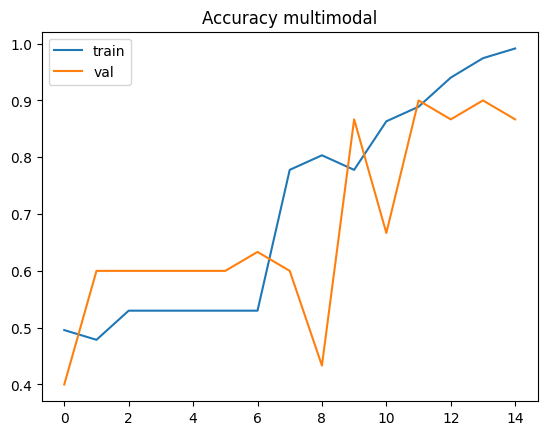

In [44]:
plt.plot(history_multi.history["accuracy"], label="train")
plt.plot(history_multi.history["val_accuracy"], label="val")
plt.legend()
plt.title("Accuracy multimodal")
plt.show()

In [45]:
print("Image seule :", accuracy_score(y_test_img, y_pred_img))
print("Multimodal :", accuracy_score(y_test_img, y_pred_multi))

Image seule : 0.5135135135135135
Multimodal : 0.8378378378378378


### Comparaison des modèles

Le modèle basé uniquement sur l’image obtient une accuracy de **51,3 %**, ce qui traduit des performances faibles. Il est proche du hasard, ce qui montre que l’image seule ne permet pas de capturer suffisamment d’informations discriminantes dans ce contexte.

En revanche, le modèle multimodal, combinant l’image et les probabilités issues du modèle tabulaire, atteint une accuracy de **83,8 %**, soit une amélioration significative.

---

### Interprétation

Cette amélioration montre que les données tabulaires apportent une information complémentaire essentielle à l’image. Les variables cliniques permettent d’orienter la décision du modèle, notamment lorsque les différences visuelles sont difficiles à détecter sur les radios thoraciques.

L’approche multimodale permet ainsi de combiner :
- une information visuelle issue de l’image ;
- une information clinique issue des données patient.

Cela permet d’obtenir un modèle plus robuste et plus performant.

---

### Conclusion

Le modèle multimodal est nettement supérieur au modèle basé uniquement sur l’image. Cette différence confirme l’intérêt de combiner plusieurs sources de données dans un contexte médical.

In [46]:
import joblib

joblib.dump(best_model, "models/model_tabulaire.pkl")
joblib.dump(scaler, "models/scaler_tab.pkl")

['models/scaler_tab.pkl']

In [47]:
cnn_model.save("models/cnn_image.keras")

In [48]:
multimodal_model.save("models/multimodal_clean.keras")